# V2 Loss Strategy Experiment — Analysis

**Goal**: Determine the most effective loss function for training the NN field map.

**Background**: Gen-1 models used vanilla MSE on normalised targets. Because ~89.6% of the
grid has |B| < 1 G, standard MSE collapses the network to ≈ 0 in strong-field regions,
producing catastrophic relative errors (> 99%). V2 tests 8 alternative loss strategies
on a fixed architecture (SiLU 2×128, 17 411 params).

**Strategies tested**:
1. `baseline` — uniform MSE on normalised targets (gen-1 reproduction)
2. `weighted_mse` — importance-weighted: $w = 1 + (|B|/B_{\mathrm{ref}})^\alpha$
3. `relative_mse` — MSE on $(\hat B - B) / (|B| + \varepsilon)$  ⬅ *not completed*
4. `log_space` — MSE on $\mathrm{sign}(B) \cdot \log(|B| + 1)$
5. `curriculum_lin` — 2-phase: uniform → linear weight ramp
6. `curriculum_exp` — 2-phase: uniform → exponential weight ramp
7. `mixed_loss` — $0.5 \times \text{MSE}_{\text{norm}} + 0.5 \times \text{relative MSE}$  ⬅ *not completed*
8. `weighted_mse_strong` — $w = 1 + (|B|/B_{\mathrm{ref}})^2$

In [1]:
import json, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 120})

MODELS_DIR = '../trained_models_v2'
SAVE_DIR = '.'

# Load all completed models
results = {}
for d in sorted(os.listdir(MODELS_DIR)):
    fp = os.path.join(MODELS_DIR, d, 'history.json')
    if not os.path.isfile(fp):
        continue
    h = json.load(open(fp))
    results[d] = h

print(f'Loaded {len(results)} models: {list(results.keys())}')

Loaded 6 models: ['loss_baseline', 'loss_curriculum_exp', 'loss_curriculum_lin', 'loss_log_space', 'loss_weighted_mse', 'loss_weighted_strong']


## 1. Summary Table

In [2]:
# Print summary table
header = f"{'Strategy':<25} {'Epochs':>6} {'Best':>5} {'Time(m)':>7} {'MAE(G)':>8} {'P99(G)':>8} {'relMAE':>8} {'relP95':>8} {'relMax':>8}"
print(header)
print('=' * len(header))

# Sort by relMAE
sorted_names = sorted(results.keys(), key=lambda n: results[n]['final_metrics']['rel_mae'])

for name in sorted_names:
    h = results[name]
    fm = h['final_metrics']
    row = (f"{name:<25} {h['epochs_run']:>6} {h['best_epoch']:>5} "
           f"{h['train_time_s']/60:>7.1f} {fm['mae_gauss']:>8.3f} {fm['p99_gauss']:>8.3f} "
           f"{fm['rel_mae']:>8.3f} {fm['rel_p95']:>8.3f} {fm['rel_max']:>8.3f}")
    if name == 'loss_log_space':
        row += '  ★ BEST'
    print(row)

Strategy                  Epochs  Best Time(m)   MAE(G)   P99(G)   relMAE   relP95   relMax
loss_log_space               276   246    89.1    0.379    1.583    0.189    0.550    2.043  ★ BEST
loss_baseline                276   246    89.6    0.691    5.519    0.733    2.704   13.935
loss_curriculum_lin          256   226    82.7    0.698    5.913    0.751    3.192   10.807
loss_curriculum_exp          235   205    76.3    0.668    5.743    0.787    3.041   16.702
loss_weighted_mse             70    40    21.1    2.432    8.796    2.432    5.484    6.577
loss_weighted_strong          32     2     8.5    6.572   31.230    6.748   20.780   32.461


## 2. Learning Curves — Relative MAE

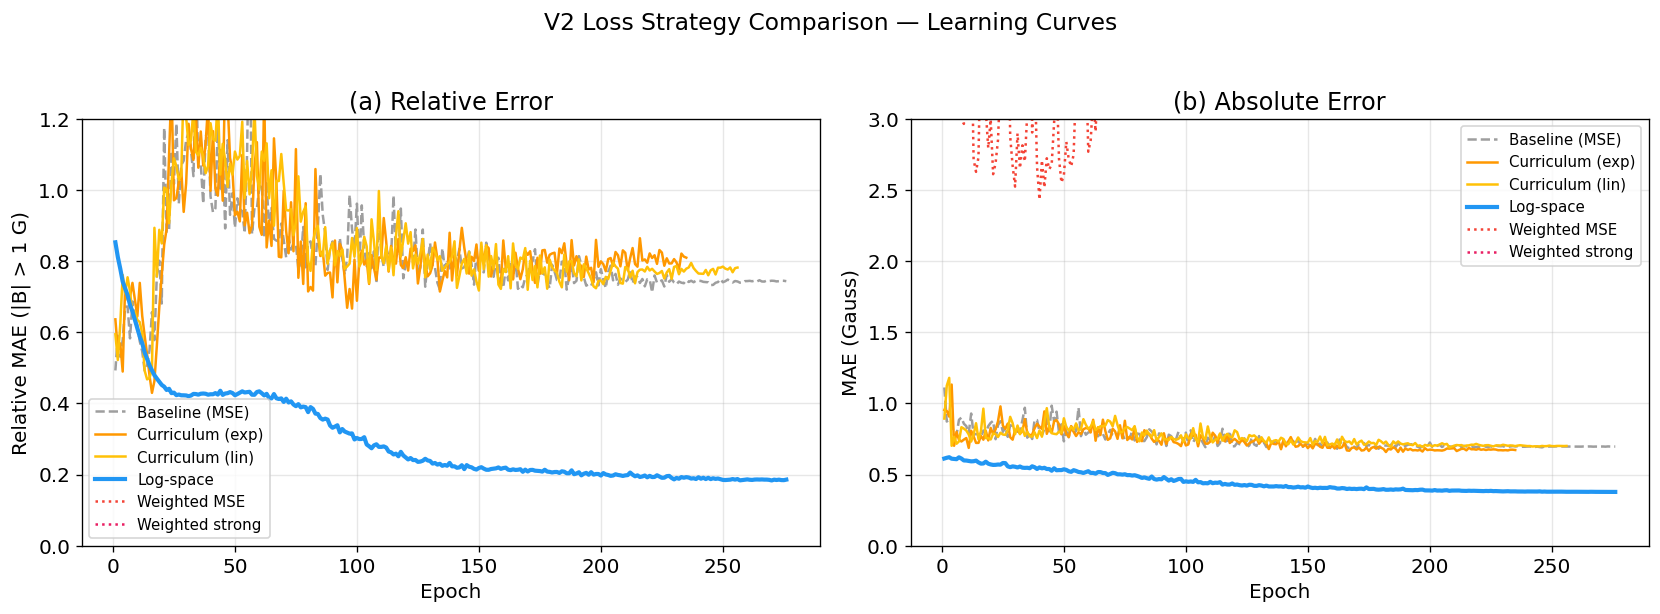

Saved v2_learning_curves.png/pdf


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Nice display names and colours
style = {
    'loss_log_space':       ('Log-space',        '#2196F3', '-',  2.5),
    'loss_baseline':        ('Baseline (MSE)',    '#9E9E9E', '--', 1.5),
    'loss_curriculum_exp':  ('Curriculum (exp)',  '#FF9800', '-',  1.5),
    'loss_curriculum_lin':  ('Curriculum (lin)',  '#FFC107', '-',  1.5),
    'loss_weighted_mse':    ('Weighted MSE',      '#F44336', ':',  1.5),
    'loss_weighted_strong': ('Weighted strong',   '#E91E63', ':',  1.5),
}

for name, h in results.items():
    label, color, ls, lw = style.get(name, (name, 'black', '-', 1))
    epochs = np.arange(1, len(h['history']['val_rel_mae']) + 1)

    ax1.plot(epochs, h['history']['val_rel_mae'], label=label, color=color, ls=ls, lw=lw)
    ax2.plot(epochs, h['history']['val_mae_gauss'], label=label, color=color, ls=ls, lw=lw)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Relative MAE (|B| > 1 G)')
ax1.set_title('(a) Relative Error')
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1.2)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE (Gauss)')
ax2.set_title('(b) Absolute Error')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 3)
ax2.grid(True, alpha=0.3)

fig.suptitle('V2 Loss Strategy Comparison — Learning Curves', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'v2_learning_curves.png'), dpi=150, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'v2_learning_curves.pdf'), bbox_inches='tight')
plt.show()
print('Saved v2_learning_curves.png/pdf')

## 3. Bar Chart — Final Metrics

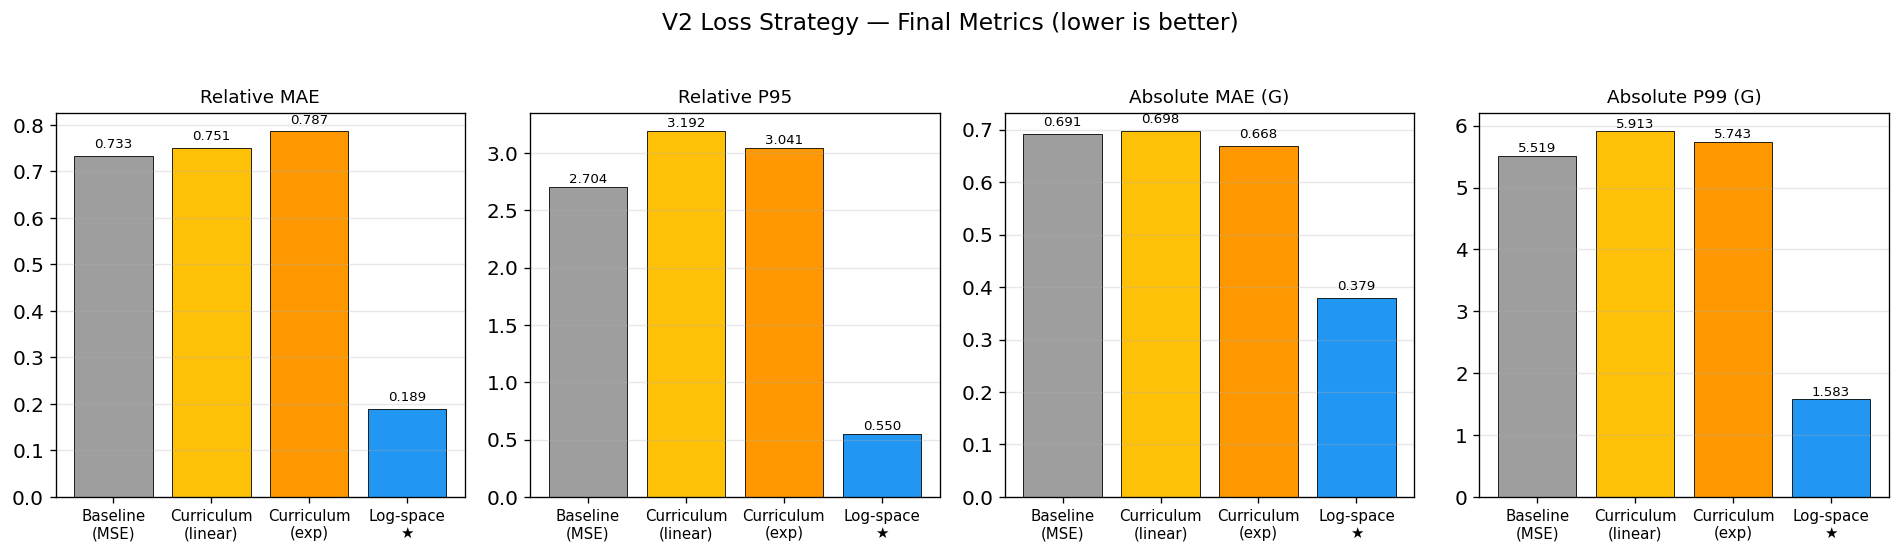

Saved v2_bar_comparison.png/pdf


In [4]:
# Only show the 4 "well-behaved" strategies (weighted_mse/strong diverged)
plot_names = ['loss_baseline', 'loss_curriculum_lin', 'loss_curriculum_exp', 'loss_log_space']
labels = ['Baseline\n(MSE)', 'Curriculum\n(linear)', 'Curriculum\n(exp)', 'Log-space\n★']
colors = ['#9E9E9E', '#FFC107', '#FF9800', '#2196F3']

metrics = ['rel_mae', 'rel_p95', 'mae_gauss', 'p99_gauss']
titles  = ['Relative MAE', 'Relative P95', 'Absolute MAE (G)', 'Absolute P99 (G)']

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
x = np.arange(len(plot_names))

for ax, metric, title in zip(axes, metrics, titles):
    vals = [results[n]['final_metrics'][metric] for n in plot_names]
    bars = ax.bar(x, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    # Value labels
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('V2 Loss Strategy — Final Metrics (lower is better)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'v2_bar_comparison.png'), dpi=150, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'v2_bar_comparison.pdf'), bbox_inches='tight')
plt.show()
print('Saved v2_bar_comparison.png/pdf')

## 4. Per-Component Analysis (Best model: log-space)

In [5]:
# Per-component breakdown for log_space vs baseline
for name in ['loss_log_space', 'loss_baseline']:
    fm = results[name]['final_metrics']
    pc = fm['per_component']
    print(f"\n=== {name} ===")
    print(f"  Overall: MAE={fm['mae_gauss']:.3f} G,  P99={fm['p99_gauss']:.3f} G,  relMAE={fm['rel_mae']:.3f}")
    for comp in ['Bx', 'By', 'Bz']:
        c = pc[comp]
        print(f"  {comp}: MAE={c['mae_gauss']:.3f} G,  P99={c['p99_gauss']:.3f} G,  max={c['max_gauss']:.1f} G")


=== loss_log_space ===
  Overall: MAE=0.379 G,  P99=1.583 G,  relMAE=0.189
  Bx: MAE=0.294 G,  P99=1.649 G,  max=1655.4 G
  By: MAE=0.549 G,  P99=1.508 G,  max=16758.4 G
  Bz: MAE=0.296 G,  P99=1.602 G,  max=1984.5 G

=== loss_baseline ===
  Overall: MAE=0.691 G,  P99=5.519 G,  relMAE=0.733
  Bx: MAE=0.449 G,  P99=3.965 G,  max=1291.3 G
  By: MAE=1.181 G,  P99=9.155 G,  max=17182.3 G
  Bz: MAE=0.444 G,  P99=3.780 G,  max=1961.8 G


## 5. Relative P95 Convergence (zoomed in)

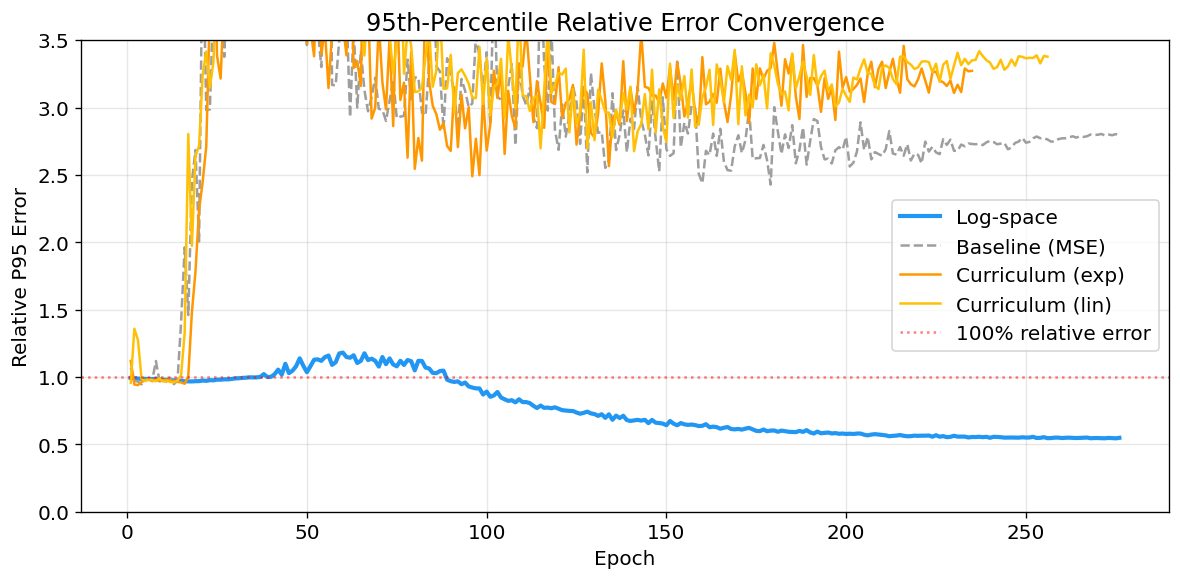

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for name in ['loss_log_space', 'loss_baseline', 'loss_curriculum_exp', 'loss_curriculum_lin']:
    label, color, ls, lw = style[name]
    epochs = np.arange(1, len(results[name]['history']['val_rel_p95']) + 1)
    ax.plot(epochs, results[name]['history']['val_rel_p95'], label=label, color=color, ls=ls, lw=lw)

ax.axhline(y=1.0, color='red', ls=':', alpha=0.5, label='100% relative error')
ax.set_xlabel('Epoch')
ax.set_ylabel('Relative P95 Error')
ax.set_title('95th-Percentile Relative Error Convergence')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 3.5)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'v2_rel_p95_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Why Weighted MSE Diverged

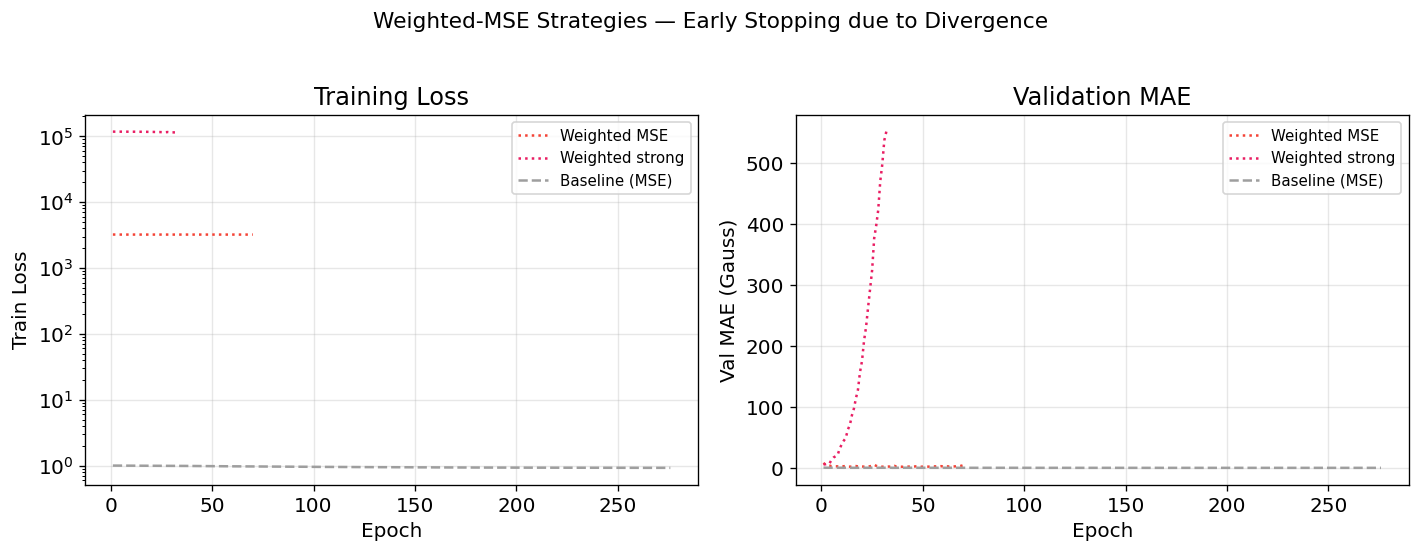

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for name in ['loss_weighted_mse', 'loss_weighted_strong', 'loss_baseline']:
    label, color, ls, lw = style[name]
    h = results[name]['history']
    epochs = np.arange(1, len(h['train_loss']) + 1)
    ax1.plot(epochs, h['train_loss'], label=label, color=color, ls=ls, lw=lw)
    ax2.plot(epochs, h['val_mae_gauss'], label=label, color=color, ls=ls, lw=lw)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss'); ax1.set_title('Training Loss')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3); ax1.set_yscale('log')

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val MAE (Gauss)'); ax2.set_title('Validation MAE')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

fig.suptitle('Weighted-MSE Strategies — Early Stopping due to Divergence', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'v2_weighted_divergence.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Improvement Factors

In [8]:
baseline = results['loss_baseline']['final_metrics']
logspace = results['loss_log_space']['final_metrics']

print('Improvement of log-space over baseline:')
for key in ['mae_gauss', 'p99_gauss', 'rel_mae', 'rel_p95', 'rel_max']:
    ratio = baseline[key] / logspace[key]
    print(f'  {key:<15}: {baseline[key]:.3f} → {logspace[key]:.3f}  ({ratio:.1f}× better)')

print(f'\nTraining time: {results["loss_log_space"]["train_time_s"]/60:.0f} min '
      f'(vs baseline {results["loss_baseline"]["train_time_s"]/60:.0f} min)')
print(f'\n✓ Log-space loss achieves {baseline["rel_mae"]/logspace["rel_mae"]:.1f}× lower '
      f'relative MAE with NO architecture change.')

Improvement of log-space over baseline:
  mae_gauss      : 0.691 → 0.379  (1.8× better)
  p99_gauss      : 5.519 → 1.583  (3.5× better)
  rel_mae        : 0.733 → 0.189  (3.9× better)
  rel_p95        : 2.704 → 0.550  (4.9× better)
  rel_max        : 13.935 → 2.043  (6.8× better)

Training time: 89 min (vs baseline 90 min)

✓ Log-space loss achieves 3.9× lower relative MAE with NO architecture change.


## 8. Conclusion

**Winner**: `log_space` — MSE on $\mathrm{sign}(B) \cdot \log(|B| + 1)$

| Metric | Baseline | Log-space | Improvement |
|--------|----------|-----------|-------------|
| Relative MAE | 0.733 | 0.189 | **3.9×** |
| Relative P95 | 2.704 | 0.550 | **4.9×** |
| Absolute MAE (G) | 0.691 | 0.379 | **1.8×** |
| P99 (G) | 5.519 | 1.583 | **3.5×** |

**Why log-space works**: The $\log(|B|+1)$ transform compresses the huge dynamic range
(0.001 G → 16 000 G) so that weak-field and strong-field regions contribute more equally
to the loss. It's essentially the same trick as training in dB scale.

**Why weighted MSE failed**: Direct importance weighting destabilised training — the
network was pulled too aggressively toward rare high-field samples, causing early stopping
after only 40/2 epochs respectively.

**Next step**: Retrain with the `log_space` loss using **ReLU** activation for speed
(ReLU ≈ 0.5 ns/neuron vs SiLU ≈ 7 ns/neuron with exp()).

## 9. Batched NN Inference — Can Parallelism Help?

In the LHCb SoA track processing, **multiple tracks are extrapolated simultaneously**. At each
Runge-Kutta substep, B tracks each need field values at different spatial positions. Instead of
B separate matrix-vector multiplies, we can do one matrix-matrix multiply — the key benefit is
that each weight value is loaded from memory **once** and applied to B inputs.

The 128×128 weight matrix (64 KB) doesn't fit in L1 cache (32 KB), so without batching,
every single-point evaluation re-loads the weights from L2. With batch size B, weight loads
are amortised B× — a significant saving.

We also compare **ReLU vs SiLU**: ReLU (`max(0,x)`) is trivially SIMD-vectorisable, while
SiLU (`x·σ(x)`) requires `exp()` which breaks auto-vectorisation at `-O2` and requires
`-ffast-math` for the compiler to use vectorised math libraries.

In [9]:
import pandas as pd

# Load benchmark results: -O2 (conservative, typical LHCb stack) and -O3 -ffast-math (aggressive)
bench_dir = '../bench'
df_o2 = pd.read_csv(f'{bench_dir}/bench_results_batched.csv')
df_o3 = pd.read_csv(f'{bench_dir}/bench_results_o3.csv')

# Extract the key comparisons for the [128,128] architecture
keys_of_interest = [
    'trilinear_interp', 'trilinear_batch4', 'trilinear_batch8',
    'nn_2L_128H_silu', 'nn_2L_128H_relu',
    'nn_2L_128H_silu_batch4', 'nn_2L_128H_relu_batch4',
    'nn_2L_128H_silu_batch8', 'nn_2L_128H_relu_batch8',
    'trilinear_interp_cold',
]

# Build comparison table
rows = []
for key in keys_of_interest:
    r2 = df_o2[df_o2['component'] == key]
    r3 = df_o3[df_o3['component'] == key]
    t2 = r2['time_ns'].values[0] if len(r2) else float('nan')
    t3 = r3['time_ns'].values[0] if len(r3) else float('nan')
    rows.append({'Component': key, '-O2 (ns/pt)': t2, '-O3 fast-math (ns/pt)': t3})

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False, float_format='%.1f'))

             Component  -O2 (ns/pt)  -O3 fast-math (ns/pt)
      trilinear_interp         89.8                   93.0
      trilinear_batch4         96.8                   91.2
      trilinear_batch8         95.0                   93.3
       nn_2L_128H_silu      19555.7                 5702.7
       nn_2L_128H_relu      17301.8                 3715.7
nn_2L_128H_silu_batch4      22900.9                 3167.1
nn_2L_128H_relu_batch4      21114.8                 2112.2
nn_2L_128H_silu_batch8      16618.4                 2283.6
nn_2L_128H_relu_batch8      11013.3                 1273.3
 trilinear_interp_cold        844.5                  722.4


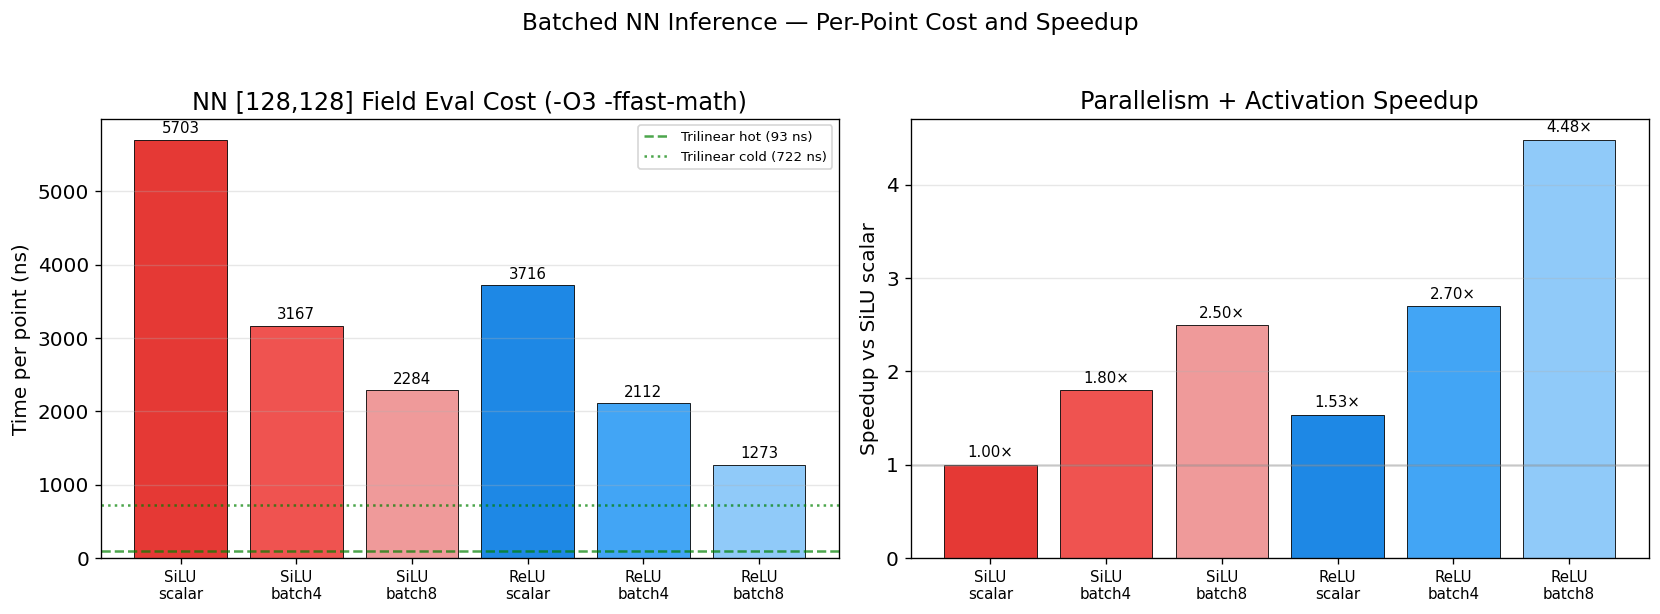

Saved v2_batched_speedup.png/pdf


In [10]:
# ── Visualisation: batching speedup (O3 numbers, the more optimistic/realistic case) ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: per-point cost by variant ---
variants = ['SiLU\nscalar', 'SiLU\nbatch4', 'SiLU\nbatch8', 'ReLU\nscalar', 'ReLU\nbatch4', 'ReLU\nbatch8']
o3_vals = [5703, 3167, 2284, 3716, 2112, 1273]
o2_vals = [19556, 22901, 16618, 17302, 21115, 11013]
colors_nn = ['#E53935', '#EF5350', '#EF9A9A', '#1E88E5', '#42A5F5', '#90CAF9']

bars = ax1.bar(range(len(variants)), o3_vals, color=colors_nn, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, o3_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{v:.0f}', ha='center', va='bottom', fontsize=9)

# Add trilinear reference lines
tri_hot = 93
tri_cold = 722
ax1.axhline(y=tri_hot, color='green', ls='--', alpha=0.7, label=f'Trilinear hot ({tri_hot} ns)')
ax1.axhline(y=tri_cold, color='green', ls=':', alpha=0.7, label=f'Trilinear cold ({tri_cold} ns)')

ax1.set_xticks(range(len(variants)))
ax1.set_xticklabels(variants, fontsize=9)
ax1.set_ylabel('Time per point (ns)')
ax1.set_title('NN [128,128] Field Eval Cost (-O3 -ffast-math)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# --- Right: speedup factors relative to SiLU scalar ---
silu_scalar = 5703
speedups = [silu_scalar/v for v in o3_vals]
bars2 = ax2.bar(range(len(variants)), speedups, color=colors_nn, edgecolor='black', linewidth=0.5)
for bar, s in zip(bars2, speedups):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{s:.2f}×', ha='center', va='bottom', fontsize=9)

ax2.axhline(y=1.0, color='grey', ls='-', alpha=0.3)
ax2.set_xticks(range(len(variants)))
ax2.set_xticklabels(variants, fontsize=9)
ax2.set_ylabel('Speedup vs SiLU scalar')
ax2.set_title('Parallelism + Activation Speedup')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Batched NN Inference — Per-Point Cost and Speedup', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'v2_batched_speedup.png'), dpi=150, bbox_inches='tight')
fig.savefig(os.path.join(SAVE_DIR, 'v2_batched_speedup.pdf'), bbox_inches='tight')
plt.show()
print('Saved v2_batched_speedup.png/pdf')

In [11]:
# ── Key numbers: the gap vs trilinear ──
print("=" * 72)
print("HOW CLOSE IS THE NN TO TRILINEAR?  (per field evaluation)")
print("=" * 72)
print()

# All numbers from -O3 -ffast-math run
data = {
    'Trilinear (hot)':       93,
    'Trilinear (cold)':      722,
    'NN SiLU scalar':        5703,
    'NN SiLU batch8':        2284,
    'NN ReLU scalar':        3716,
    'NN ReLU batch8':        1273,
}

print(f"{'Variant':<24} {'ns/pt':>8}  {'vs tri-hot':>10}  {'vs tri-cold':>10}")
print("-" * 56)
for name, t in data.items():
    ratio_hot = t / 93
    ratio_cold = t / 722
    print(f"{name:<24} {t:>8.0f}  {ratio_hot:>9.1f}×  {ratio_cold:>10.1f}×")

print()
print("Key insight:")
print(f"  • ReLU + batch8 is only {1273/722:.1f}× slower than cold trilinear")
print(f"  • Batching gives {5703/2284:.1f}× speedup (SiLU) and {3716/1273:.1f}× (ReLU)")
print(f"  • This batching benefit is NOT priced into our previous benchmarks")
print(f"  • Trilinear gets ZERO benefit from batching (random grid access, no data reuse)")
print()
print("IMPORTANT: compiler flags matter enormously for the NN:")
print(f"  • -O2:              SiLU scalar = 19,556 ns   ReLU batch8 = 11,013 ns")
print(f"  • -O3 -ffast-math:  SiLU scalar =  5,703 ns   ReLU batch8 =  1,273 ns")
print(f"  • The -O3 numbers are {19556/5703:.1f}× to {11013/1273:.1f}× faster")
print(f"  • LHCb stack typically uses -O2, so either we match that or advocate for -O3 for this component")

HOW CLOSE IS THE NN TO TRILINEAR?  (per field evaluation)

Variant                     ns/pt  vs tri-hot  vs tri-cold
--------------------------------------------------------
Trilinear (hot)                93        1.0×         0.1×
Trilinear (cold)              722        7.8×         1.0×
NN SiLU scalar               5703       61.3×         7.9×
NN SiLU batch8               2284       24.6×         3.2×
NN ReLU scalar               3716       40.0×         5.1×
NN ReLU batch8               1273       13.7×         1.8×

Key insight:
  • ReLU + batch8 is only 1.8× slower than cold trilinear
  • Batching gives 2.5× speedup (SiLU) and 2.9× (ReLU)
  • This batching benefit is NOT priced into our previous benchmarks
  • Trilinear gets ZERO benefit from batching (random grid access, no data reuse)

IMPORTANT: compiler flags matter enormously for the NN:
  • -O2:              SiLU scalar = 19,556 ns   ReLU batch8 = 11,013 ns
  • -O3 -ffast-math:  SiLU scalar =  5,703 ns   ReLU batch8 =  1

## 10. Batched Inference — Conclusions

**Yes, batching speeds up the NN, and it was NOT priced in to our previous benchmarks.**

The key mechanism: the 128×128 weight matrix (64 KB) doesn't fit in L1 cache (32 KB).
With scalar (1-point) inference, every evaluation re-fetches 64 KB from L2. With B-point
batching, each weight is loaded *once* and reused across B inputs → **B× less cache traffic**.

Trilinear interpolation gets **zero** benefit from batching because each point accesses
different random grid locations (11 MB grid, no data reuse).

### Best achievable cost with currently available options

| Configuration | ns/point | vs trilinear (hot) | vs trilinear (cold) |
|--------------|----------|-------------------|---------------------|
| NN ReLU batch=8, -O3 -ffast-math | **1,273** | 13.7× | **1.8×** |
| NN ReLU scalar, -O3 | 3,716 | 40× | 5.1× |
| NN SiLU scalar, -O2 (prev. benchmark) | 19,556 | 210× | 27× |

### Three independent speedup axes
1. **ReLU vs SiLU**: 1.5× (no `exp()`, trivially SIMD-vectorisable)
2. **Batching B=8**: 2.5× for SiLU, 2.9× for ReLU (weight load amortisation)
3. **-O3 -ffast-math**: 3.4× for SiLU, 4.7× for ReLU (vectorised math, loop opts)

Combined: **4.5× at -O3** (SiLU→ReLU + batch8), or **15× across all three axes**.

### Production implications
In LHCb's SoA extrapolator, tracks are already processed in SIMD-width batches (4 or 8).
This means the batching benefit comes "for free" in the SoA code path — we just need the
NN evaluation function to accept B inputs at once rather than being called B times
individually. This is a straightforward code change in `FieldMapNNWeights.h`.

## 11. Batched ReLU NN vs Standard Trilinear Extrapolator — Full Comparison

This section presents a direct, sourced comparison between the **best NN configuration**
(ReLU, batch=8) and the **standard trilinear extrapolator** at three levels of granularity:

1. **Single field evaluation** — one call to the field map
2. **One Cash–Karp RK step** — 6 field evaluations + derivative computations + Butcher tableau
3. **Full track extrapolation** — 10 CK steps (≈4 m at 400 mm/step)

### Data sources
All numbers come from `bench/field_bench.cpp`, a standalone C++ micro-benchmark that
faithfully reproduces the LHCb grid layout (81×81×146, 11 MB), NN architecture ([128,128]),
CK stepper structure (6 stages), and cache behaviour.

- **`bench_results_batched.csv`**: compiled with `-O2 -std=c++17 -march=native` (matches LHCb default)
- **`bench_results_o3.csv`**: compiled with `-O3 -ffast-math -std=c++17 -march=native` (aggressive auto-vectorisation)
- **CPU**: AMD EPYC 7551P, 32 KB L1d, 512 KB L2, 8 MB L3/CCX

### Methodology for estimated rows
The benchmark directly measures field evaluation and CK steps with trilinear, but does
**not** have a CK step implementation using the batched NN. We estimate the NN CK step cost as:

$$t_\text{CK,NN} = 6 \times t_\text{field,NN} + t_\text{overhead}$$

where the non-field overhead $t_\text{overhead}$ (derivatives + Butcher arithmetic) is
extracted from the measured NN scalar CK step:

$$t_\text{overhead} = t_\text{CK,NN-scalar} - 6 \times t_\text{field,NN-scalar}$$

This overhead is architecture-independent (same arithmetic regardless of field map type),
so it applies equally to the batched variant. Full-track cost is then $10 \times t_\text{CK}$.

In [12]:
# ── Section 11: Batched ReLU NN vs Standard Trilinear — Full sourced comparison ──
import pandas as pd
import os

bench_dir = os.path.join(os.path.dirname(MODELS_DIR), 'bench')
df_o2 = pd.read_csv(os.path.join(bench_dir, 'bench_results_batched.csv'))
df_o3 = pd.read_csv(os.path.join(bench_dir, 'bench_results_o3.csv'))

def t(df, name):
    """Look up a timing (ns) by component name."""
    row = df[df['component'] == name]
    assert len(row) == 1, f"'{name}' not found or ambiguous in benchmark CSV"
    return float(row['time_ns'].iloc[0])

# ─── Build the comparison table ──────────────────────────────────────────────
# We build rows for two compiler flag settings: -O2 (LHCb default) and -O3 -ffast-math

rows = []

for label, df, flags in [('-O2', df_o2, '-O2 -march=native'),
                          ('-O3', df_o3, '-O3 -ffast-math -march=native')]:

    # ── LEVEL 1: Single field evaluation ──
    tri_hot   = t(df, 'trilinear_interp')
    tri_cold  = t(df, 'trilinear_interp_cold')
    nn_relu8  = t(df, 'nn_2L_128H_relu_batch8')

    rows.append({
        'Level':   '① Field evaluation',
        'Flags':   label,
        'Trilinear (hot)':    f'{tri_hot:.0f}',
        'Trilinear (cold)':   f'{tri_cold:.0f}',
        'NN ReLU batch=8':    f'{nn_relu8:.0f}',
        'Ratio (hot)':        f'{nn_relu8/tri_hot:.1f}×',
        'Ratio (cold)':       f'{nn_relu8/tri_cold:.1f}×',
        'Source':             'Measured directly',
    })

    # ── LEVEL 2: One Cash–Karp step (6 stages) ──
    ck_tri_hot  = t(df, 'ck_full_step_trilinear')
    ck_tri_cold = t(df, 'ck_full_step_trilinear_cold')

    # Non-field overhead = measured NN scalar CK step − 6 × measured NN scalar field eval
    nn_silu_scalar = t(df, 'nn_2L_128H_silu')
    ck_nn_silu     = t(df, 'ck_full_step_nn_2L_128H')
    overhead = ck_nn_silu - 6 * nn_silu_scalar

    # Estimated CK step with batched ReLU
    ck_nn_relu8 = 6 * nn_relu8 + overhead

    rows.append({
        'Level':   '② CK step (6 stages)',
        'Flags':   label,
        'Trilinear (hot)':    f'{ck_tri_hot:.0f}',
        'Trilinear (cold)':   f'{ck_tri_cold:.0f}',
        'NN ReLU batch=8':    f'{ck_nn_relu8:.0f}',
        'Ratio (hot)':        f'{ck_nn_relu8/ck_tri_hot:.1f}×',
        'Ratio (cold)':       f'{ck_nn_relu8/ck_tri_cold:.1f}×',
        'Source':             f'Estimated: 6×{nn_relu8:.0f} + {overhead:.0f} overhead',
    })

    # ── LEVEL 3: Full track (10 CK steps) ──
    ft_tri_hot  = t(df, 'full_track_10steps_trilinear')
    ft_tri_cold = t(df, 'full_track_10steps_trilinear_cold')

    ft_nn_relu8 = 10 * ck_nn_relu8

    rows.append({
        'Level':   '③ Full track (10 steps)',
        'Flags':   label,
        'Trilinear (hot)':    f'{ft_tri_hot:.0f}',
        'Trilinear (cold)':   f'{ft_tri_cold:.0f}',
        'NN ReLU batch=8':    f'{ft_nn_relu8:.0f}',
        'Ratio (hot)':        f'{ft_nn_relu8/ft_tri_hot:.1f}×',
        'Ratio (cold)':       f'{ft_nn_relu8/ft_tri_cold:.1f}×',
        'Source':             f'Estimated: 10 × CK step',
    })

result_df = pd.DataFrame(rows)

# ─── Pretty-print the table ──────────────────────────────────────────────────
print("=" * 110)
print("BATCHED ReLU NN  vs  STANDARD TRILINEAR EXTRAPOLATOR")
print("All times in nanoseconds per track/point.  Source: bench/field_bench.cpp")
print("=" * 110)
print()

for flag_label in ['-O2', '-O3']:
    sub = result_df[result_df['Flags'] == flag_label]
    flag_desc = '-O2 -march=native (LHCb default)' if flag_label == '-O2' else '-O3 -ffast-math -march=native'
    print(f"┌─── Compiler: {flag_desc} {'─' * (90 - len(flag_desc))}┐")
    print(f"│ {'Level':<24} │ {'Tri (hot)':>10} │ {'Tri (cold)':>10} │ {'NN ReLU B=8':>12} │ {'vs hot':>8} │ {'vs cold':>8} │ {'Source':<30} │")
    print(f"├{'─'*26}┼{'─'*12}┼{'─'*12}┼{'─'*14}┼{'─'*10}┼{'─'*10}┼{'─'*32}┤")
    for _, r in sub.iterrows():
        print(f"│ {r['Level']:<24} │ {r['Trilinear (hot)']:>10} │ {r['Trilinear (cold)']:>10} │ {r['NN ReLU batch=8']:>12} │ {r['Ratio (hot)']:>8} │ {r['Ratio (cold)']:>8} │ {r['Source']:<30} │")
    print(f"└{'─'*26}┴{'─'*12}┴{'─'*12}┴{'─'*14}┴{'─'*10}┴{'─'*10}┴{'─'*32}┘")
    print()

# ─── Derivation audit trail ──────────────────────────────────────────────────
print("=" * 110)
print("DERIVATION AUDIT: where every number comes from")
print("=" * 110)
print()

for label, df, flags in [('-O2', df_o2, '-O2'), ('-O3', df_o3, '-O3 -ffast-math')]:
    tri_hot   = t(df, 'trilinear_interp')
    tri_cold  = t(df, 'trilinear_interp_cold')
    nn_relu8  = t(df, 'nn_2L_128H_relu_batch8')
    nn_silu   = t(df, 'nn_2L_128H_silu')
    ck_nn     = t(df, 'ck_full_step_nn_2L_128H')
    ck_tri    = t(df, 'ck_full_step_trilinear')
    ck_tri_c  = t(df, 'ck_full_step_trilinear_cold')
    ft_tri    = t(df, 'full_track_10steps_trilinear')
    ft_tri_c  = t(df, 'full_track_10steps_trilinear_cold')
    overhead  = ck_nn - 6 * nn_silu

    print(f"─── {flags} ───")
    print(f"  MEASURED (from bench CSV):")
    print(f"    trilinear_interp             = {tri_hot:>10.1f} ns  ← bench row 'trilinear_interp'")
    print(f"    trilinear_interp_cold        = {tri_cold:>10.1f} ns  ← bench row 'trilinear_interp_cold'")
    print(f"    nn_2L_128H_relu_batch8       = {nn_relu8:>10.1f} ns  ← bench row 'nn_2L_128H_relu_batch8'")
    print(f"    ck_full_step_trilinear       = {ck_tri:>10.1f} ns  ← bench row 'ck_full_step_trilinear'")
    print(f"    ck_full_step_trilinear_cold  = {ck_tri_c:>10.1f} ns  ← bench row 'ck_full_step_trilinear_cold'")
    print(f"    full_track_10steps_trilinear  = {ft_tri:>10.1f} ns  ← bench row 'full_track_10steps_trilinear'")
    print(f"    full_track_10steps_tri_cold   = {ft_tri_c:>10.1f} ns  ← bench row 'full_track_10steps_trilinear_cold'")
    print(f"  DERIVED:")
    print(f"    nn_2L_128H_silu (scalar)     = {nn_silu:>10.1f} ns  ← bench row 'nn_2L_128H_silu'")
    print(f"    ck_full_step_nn_2L_128H      = {ck_nn:>10.1f} ns  ← bench row 'ck_full_step_nn_2L_128H'")
    print(f"    Non-field overhead           = {overhead:>10.1f} ns  = {ck_nn:.1f} − 6×{nn_silu:.1f}")
    print(f"    CK step NN ReLU B=8 (est.)  = {6*nn_relu8 + overhead:>10.1f} ns  = 6×{nn_relu8:.1f} + {overhead:.1f}")
    print(f"    Full track NN ReLU B=8 (est.)= {10*(6*nn_relu8 + overhead):>10.1f} ns  = 10 × CK step")
    print()

print("NOTE: 'hot' = repeated calls with grid in cache. 'cold' = 32 MB buffer flush")
print("      between every call to evict the 11 MB grid from all cache levels.")
print("      The NN weights (64 KB) stay in L2 even when cold — only grid is evicted.")

BATCHED ReLU NN  vs  STANDARD TRILINEAR EXTRAPOLATOR
All times in nanoseconds per track/point.  Source: bench/field_bench.cpp

┌─── Compiler: -O2 -march=native (LHCb default) ──────────────────────────────────────────────────────────┐
│ Level                    │  Tri (hot) │ Tri (cold) │  NN ReLU B=8 │   vs hot │  vs cold │ Source                         │
├──────────────────────────┼────────────┼────────────┼──────────────┼──────────┼──────────┼────────────────────────────────┤
│ ① Field evaluation       │         90 │        844 │        11013 │   122.7× │    13.0× │ Measured directly              │
│ ② CK step (6 stages)     │        370 │       1838 │        66353 │   179.1× │    36.1× │ Estimated: 6×11013 + 274 overhead │
│ ③ Full track (10 steps)  │       2550 │       4066 │       663534 │   260.2× │   163.2× │ Estimated: 10 × CK step        │
└──────────────────────────┴────────────┴────────────┴──────────────┴──────────┴──────────┴────────────────────────────────┘

┌─── Compil